#This is doing the same stuff for the TC_NEW_ANALYSIS, just faster, and reuse its results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PIXEL_FOLDER = Path(
    ""  # Enter your file path/folder path in this place
    'Pervoskite Space(Master)/Data/ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/pixel'
)
SPECTRA_FILE = Path(
    ""  # Enter your file path/folder path in this place
    'Pervoskite Space(Master)/Data/ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/tauc_metrics_test.csv'
)
URBACH_FILE = Path(
    ""  # Enter your file path/folder path in this place
    'Pervoskite Space(Master)/Data/ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/urbach_metrics_test.csv'
)
TEMPERATURE_FILE = Path(
    ""  # Enter your file path/folder path in this place
    'Pervoskite Space(Master)/Data/ThermalCycling/TC_1709_50Cycle/TC_1909_IV/TC_log/temperature_log.csv'
)


def load_csv(path: Path) -> pd.DataFrame:
    """Read a CSV file and raise a helpful error when it fails."""
    try:
        return pd.read_csv(path)
    except Exception as exc:
        raise ValueError(f'Failed to load CSV at {path}: {exc}') from exc


pixel_csv_paths = sorted(PIXEL_FOLDER.glob('*.csv'))
if not pixel_csv_paths:
    raise FileNotFoundError(f'No pixel CSV files found in {PIXEL_FOLDER}')

pixel_frames = []
for csv_path in pixel_csv_paths:
    frame = load_csv(csv_path)
    frame['source_file'] = csv_path.stem
    pixel_frames.append(frame)

pixel_df = pd.concat(pixel_frames, ignore_index=True)
spectra_df = load_csv(SPECTRA_FILE)
urbach_df = load_csv(URBACH_FILE)
temperature_df = load_csv(TEMPERATURE_FILE)


In [2]:
# Prepare numeric arrays for pixel metrics and chamber temperature

def _column_to_array(frame: pd.DataFrame, column: str) -> np.ndarray:
    """Coerce a DataFrame column to a float NumPy array."""
    return pd.to_numeric(frame[column], errors='coerce').to_numpy(dtype=float)


PIXEL_PARAM_COLUMNS = {
    'Voc': 'Voc [V]',
    'Isc': 'Isc[mA/cm2]',
    'FF': 'FF',
    'PCE': 'PCE [%]',
    'Rs': 'Rs',
    'Rp': 'Rp',
}

pixel_groups = {
    name: group.reset_index(drop=True)
    for name, group in pixel_df.groupby('source_file')
}

per_pixel_arrays = {}
for file_stem, group in pixel_groups.items():
    prefix = file_stem.split('_')[0]
    timestamp_s = _column_to_array(group, 'Timestamp[s]')
    arrays = {
        'Timestamp_s': timestamp_s,
        'Timestamp_h': timestamp_s / 3600.0,
    }
    for label, column in PIXEL_PARAM_COLUMNS.items():
        arrays[label] = _column_to_array(group, column)
    per_pixel_arrays[prefix] = arrays
    for label, values in arrays.items():
        globals()[f"{prefix}_{label}"] = values

# Legacy combined arrays remain available if needed
pixel_timestamp_s = _column_to_array(pixel_df, 'Timestamp[s]')
pixel_timestamp_h = pixel_timestamp_s / 3600.0
pixel_voc = _column_to_array(pixel_df, 'Voc [V]')
pixel_isc = _column_to_array(pixel_df, 'Isc[mA/cm2]')
pixel_ff = _column_to_array(pixel_df, 'FF')
pixel_pce = _column_to_array(pixel_df, 'PCE [%]')
pixel_rs = _column_to_array(pixel_df, 'Rs')
pixel_rp = _column_to_array(pixel_df, 'Rp')

def _extract_temperature_series(df: pd.DataFrame, candidates, *, scale_default=1.0) -> np.ndarray:
    for entry in candidates:
        if isinstance(entry, tuple):
            column, scale = entry
        else:
            column, scale = entry, scale_default
        if column in df.columns:
            series = pd.to_numeric(df[column], errors='coerce') * scale
            values = series.to_numpy(dtype=float)
            if np.isnan(values).all():
                continue
            return values
    raise KeyError(
        f"None of the expected temperature columns were found: {[c if isinstance(c, str) else c[0] for c in candidates]}"
    )


TEMPERATURE_TIME_CANDIDATES = (
    ('Elapsed_s', 1 / 3600.0),
    ('elapsed_seconds', 1 / 3600.0),
    ('elapsed_s', 1 / 3600.0),
    ('measurement_time_s', 1 / 3600.0),
    ('measurement_time_h', 1.0),
    ('elapsed_hours', 1.0),
    ('Elapsed_h', 1.0),
    ('time_hours', 1.0),
    ('Time [h]', 1.0),
    ('timestamp(in Hour):', 1.0),
)

temperature_df = load_csv(TEMPERATURE_FILE)
TEMPERATURE_VALUE_CANDIDATES = (
    'Temp_A_C',
    'Temp [C]',
    'Temperature [C]',
    'temperature',
    'temperature_c',
    'temperature_C',
    'measured_temperature_C',
)

temperature_timestamp_h = _extract_temperature_series(
    temperature_df,
    TEMPERATURE_TIME_CANDIDATES,
)
temperature_values_c = _extract_temperature_series(
    temperature_df,
    TEMPERATURE_VALUE_CANDIDATES,
)


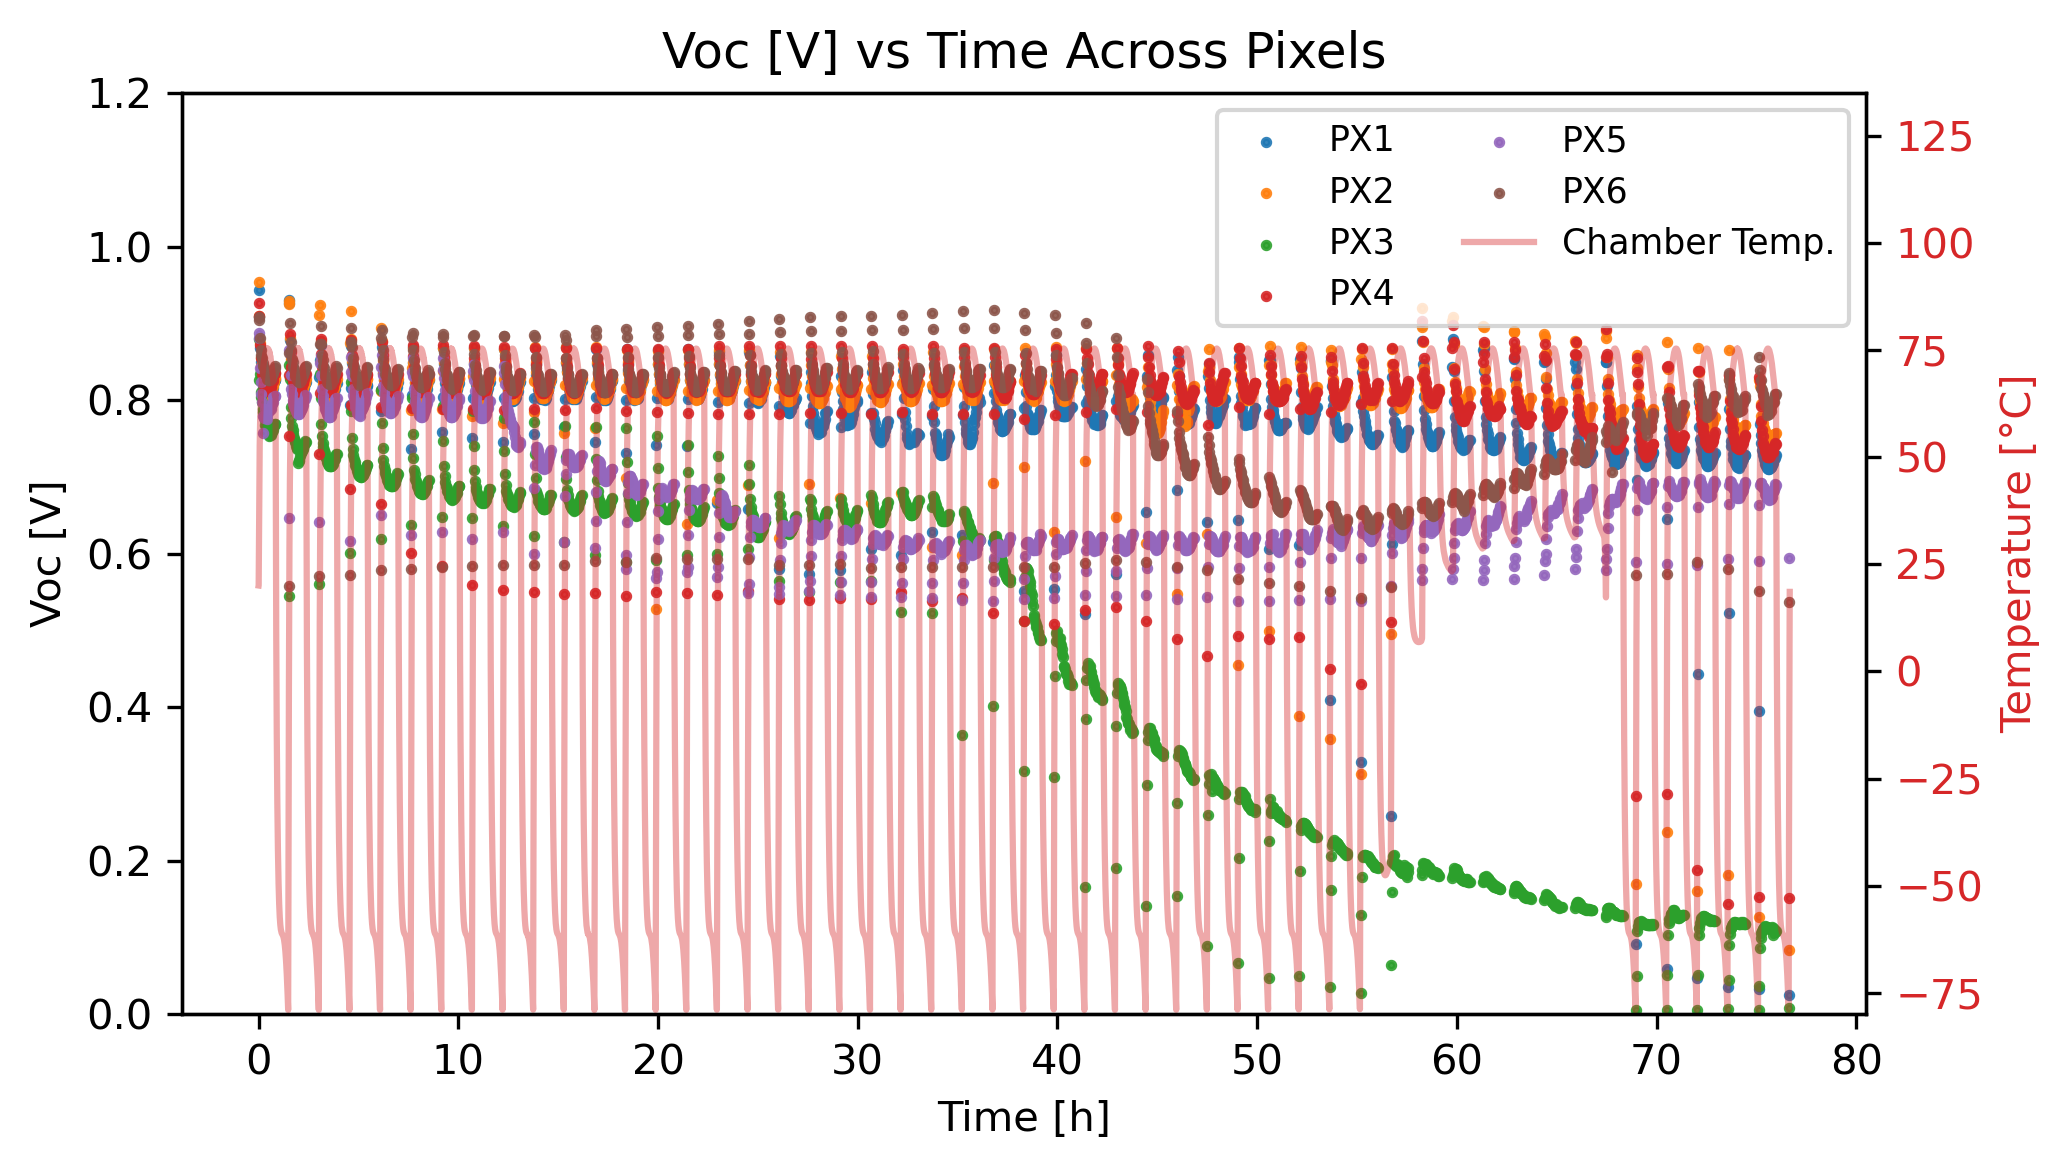

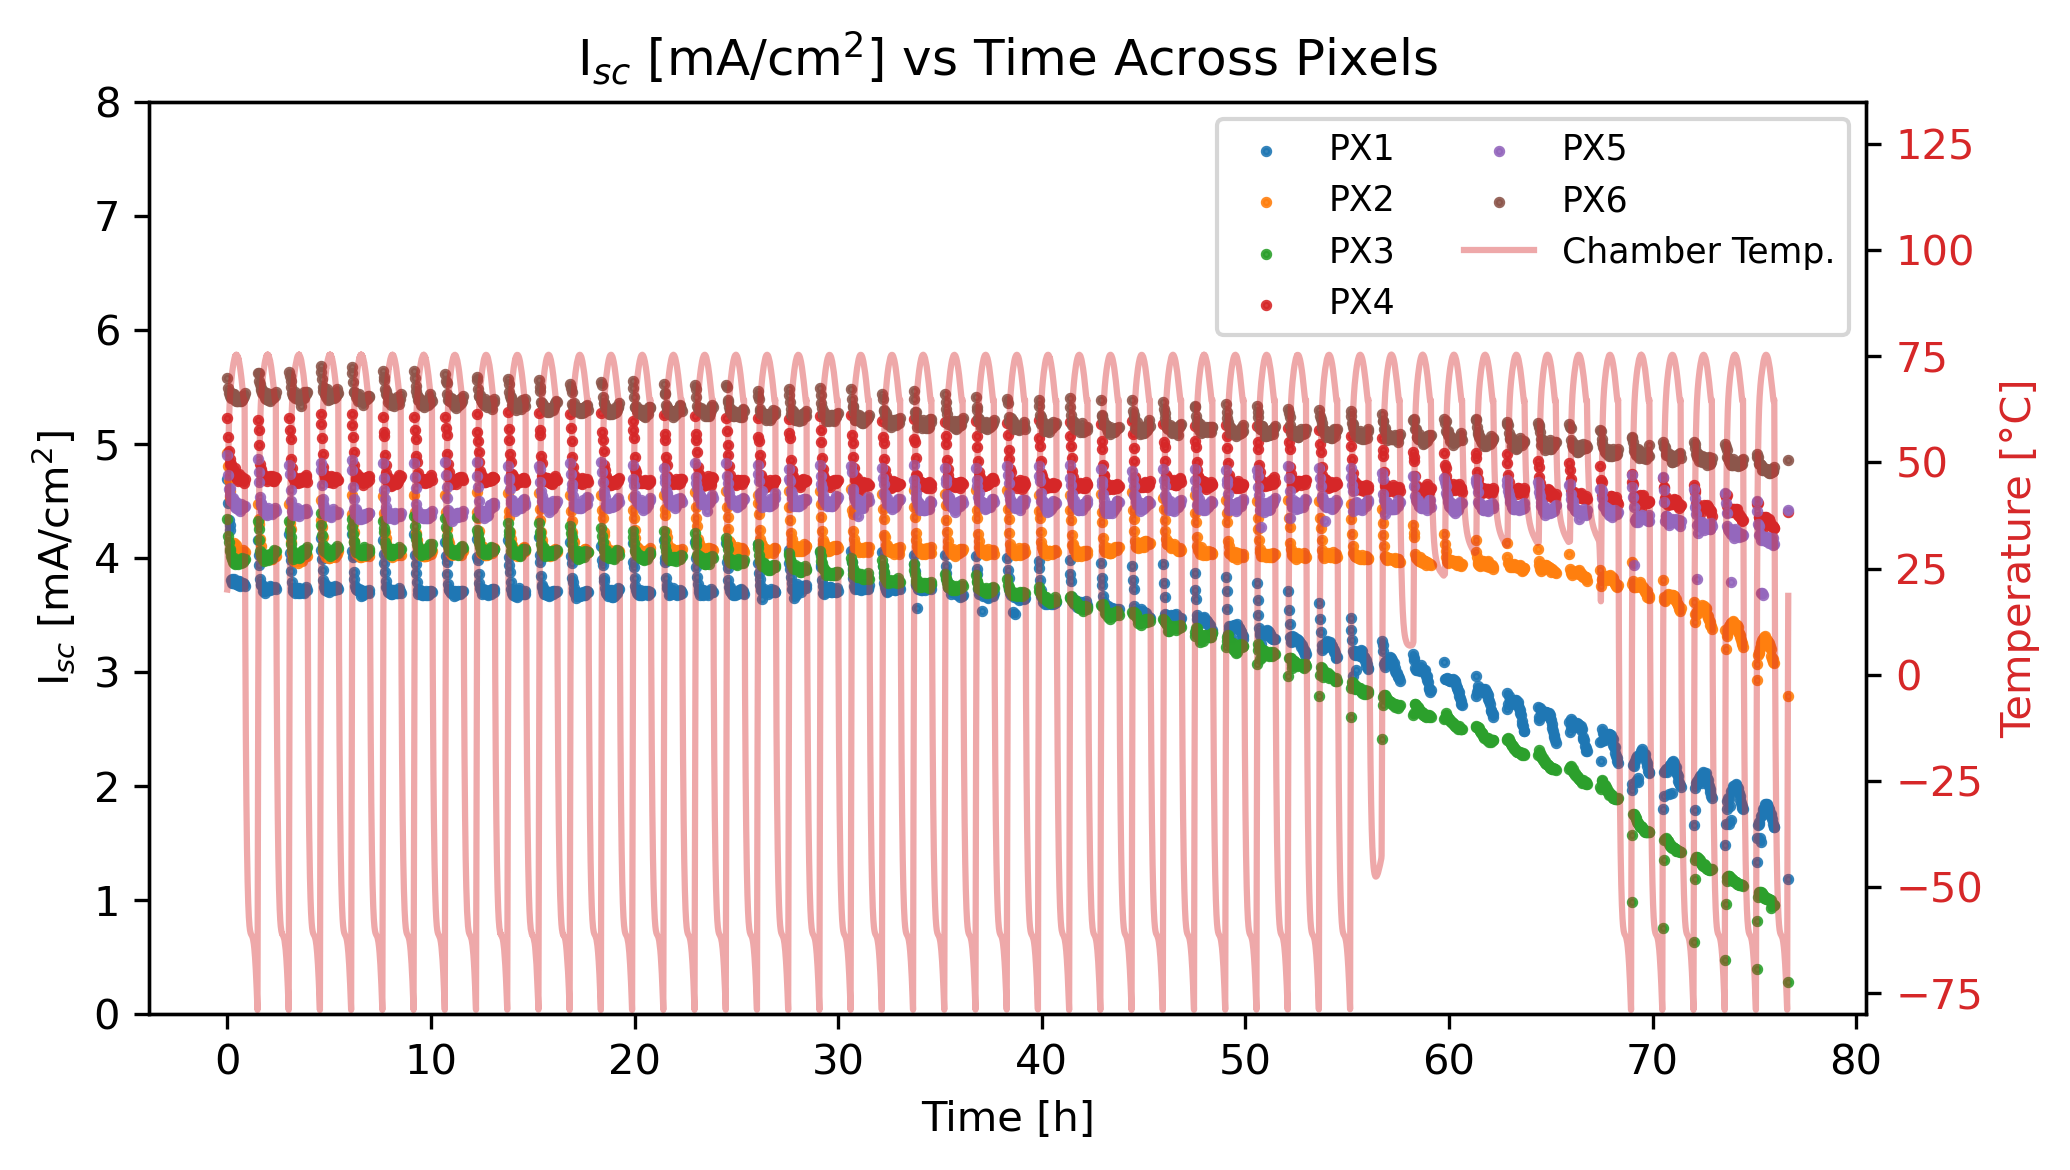

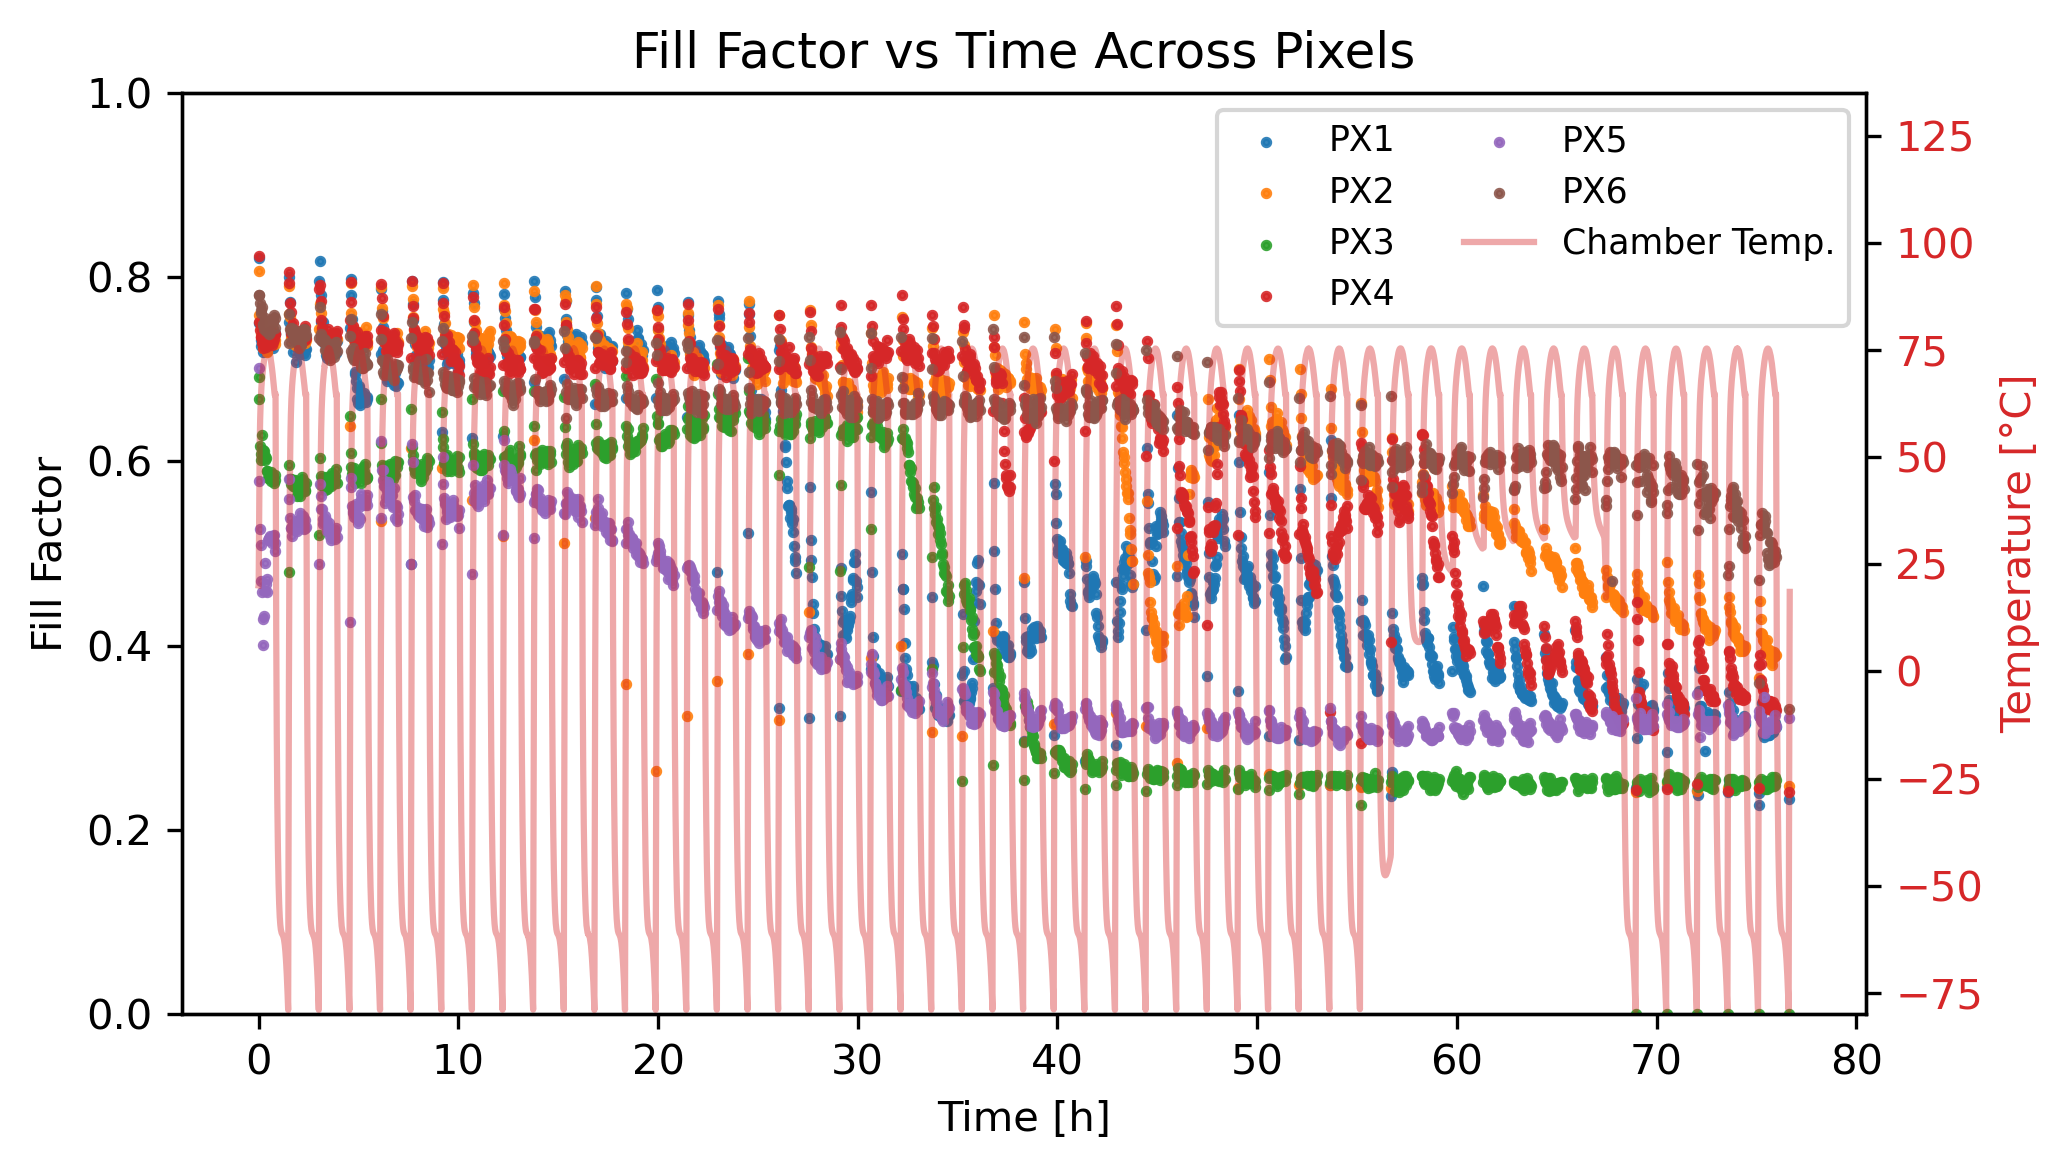

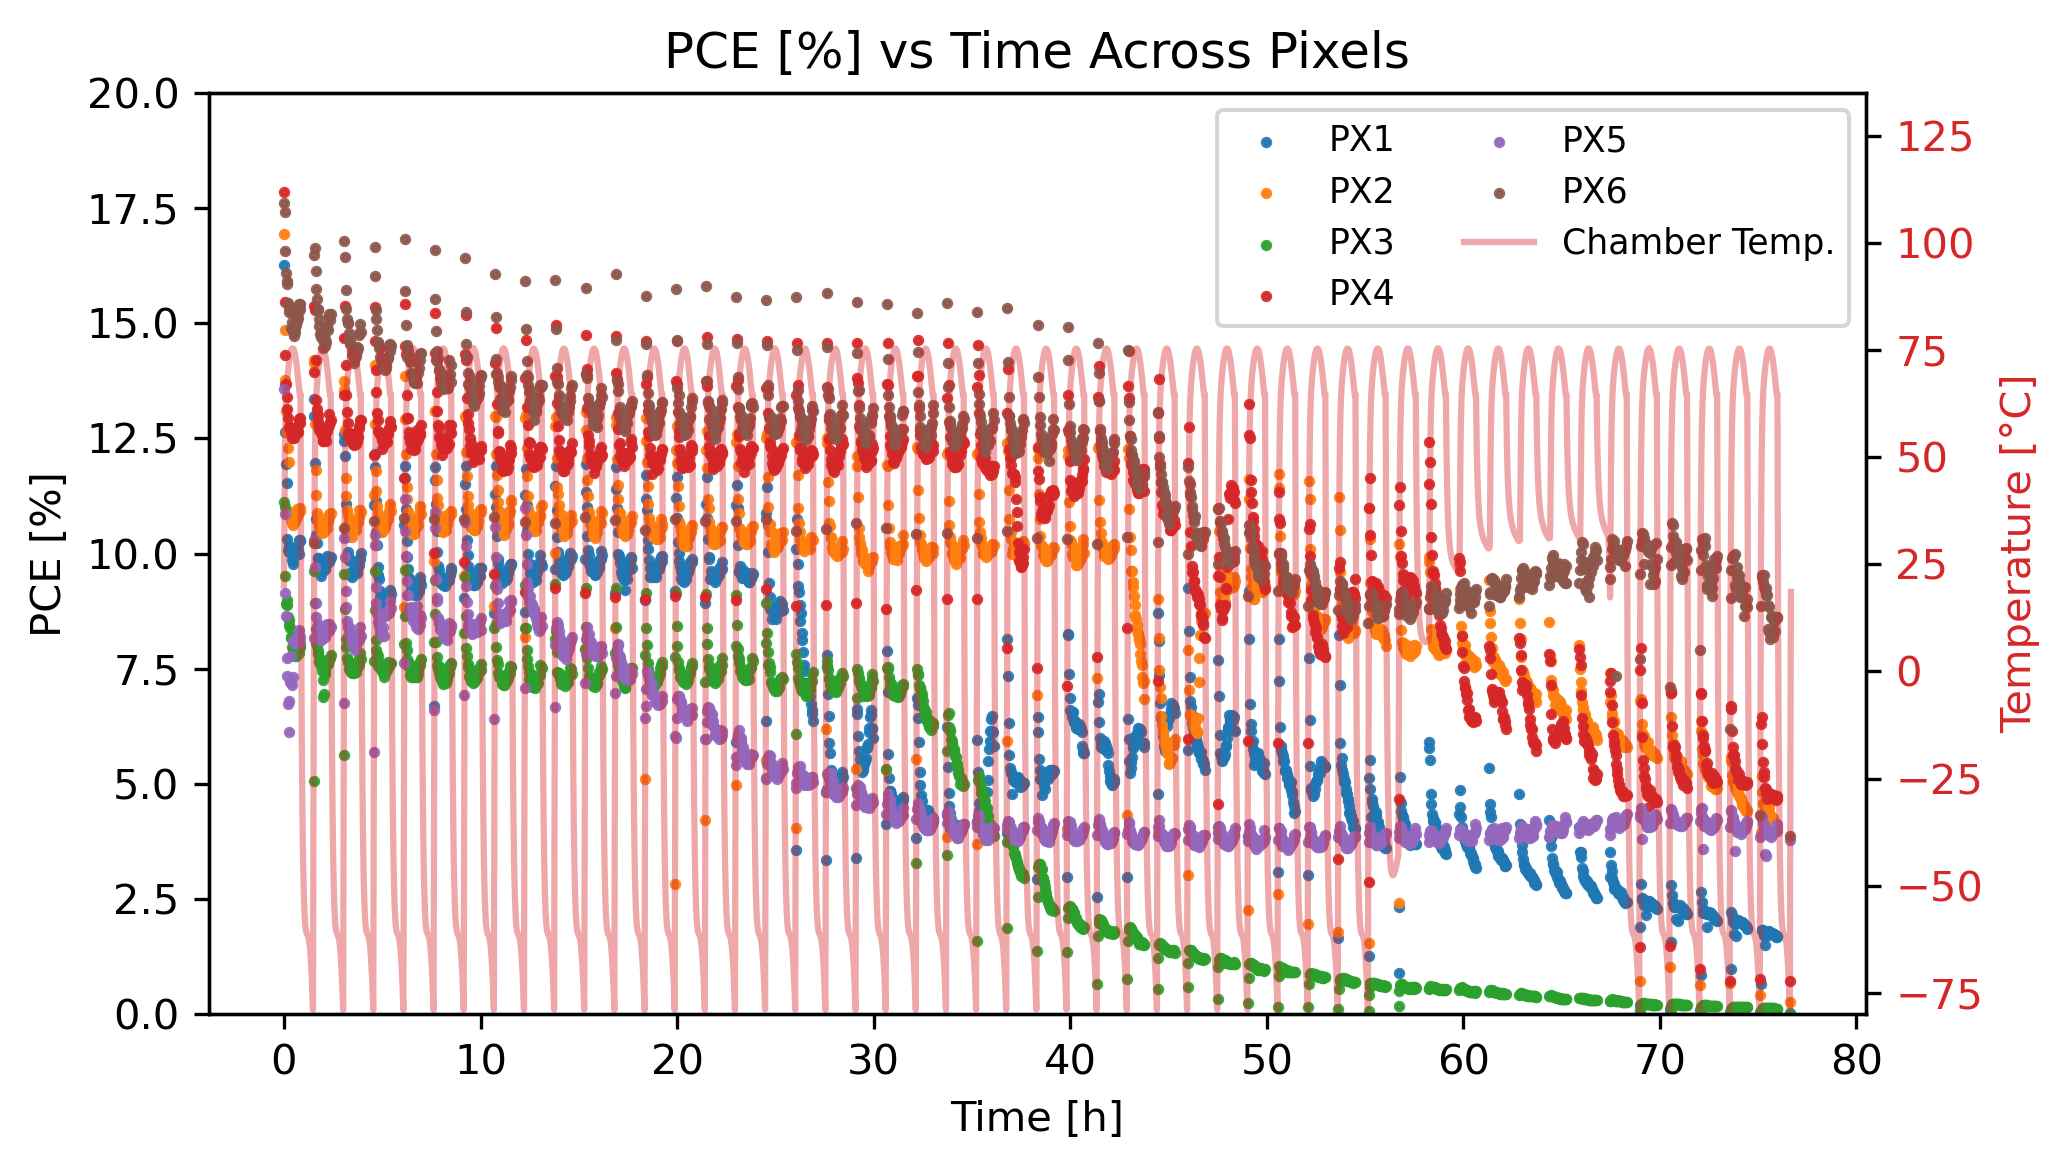

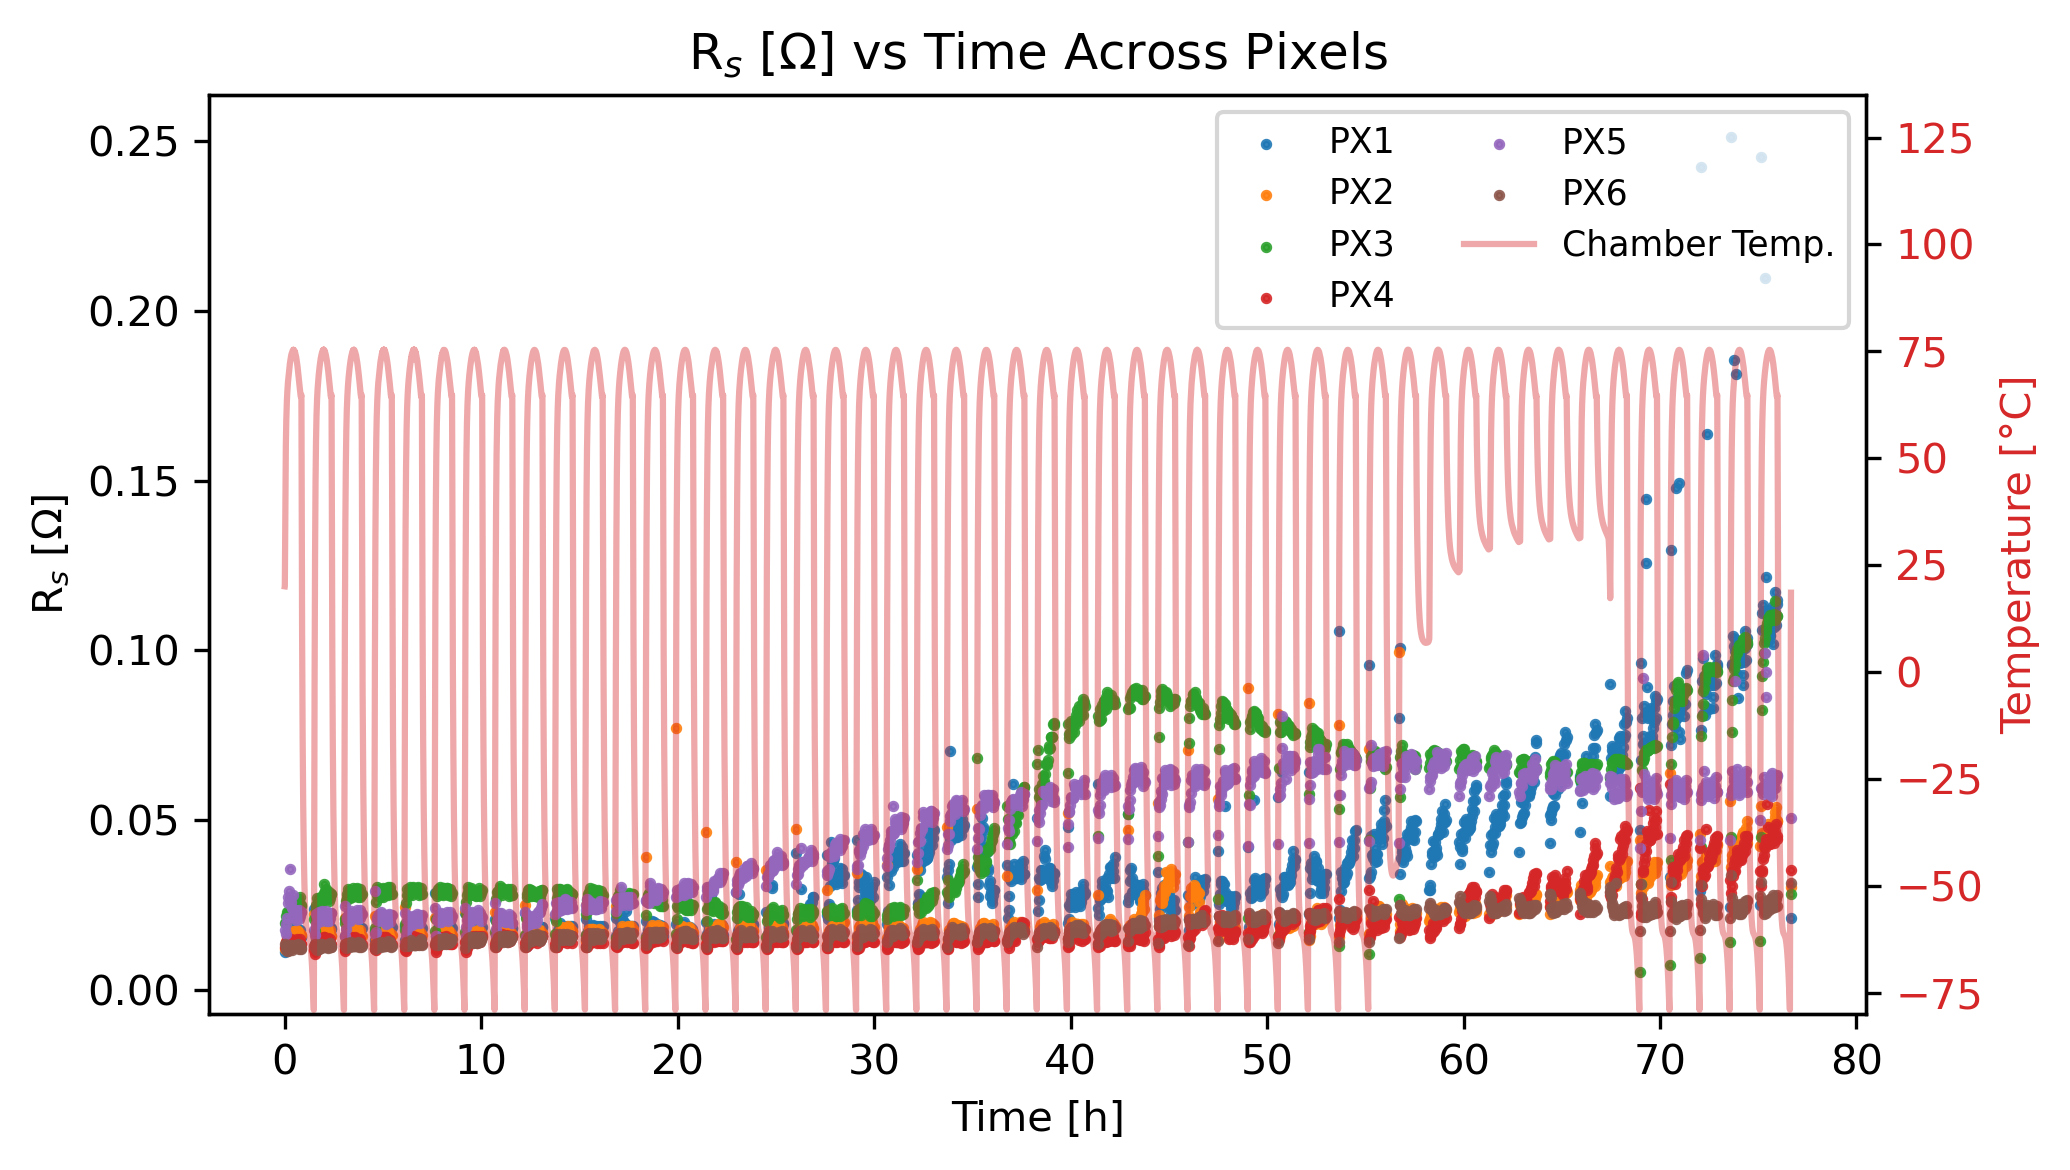

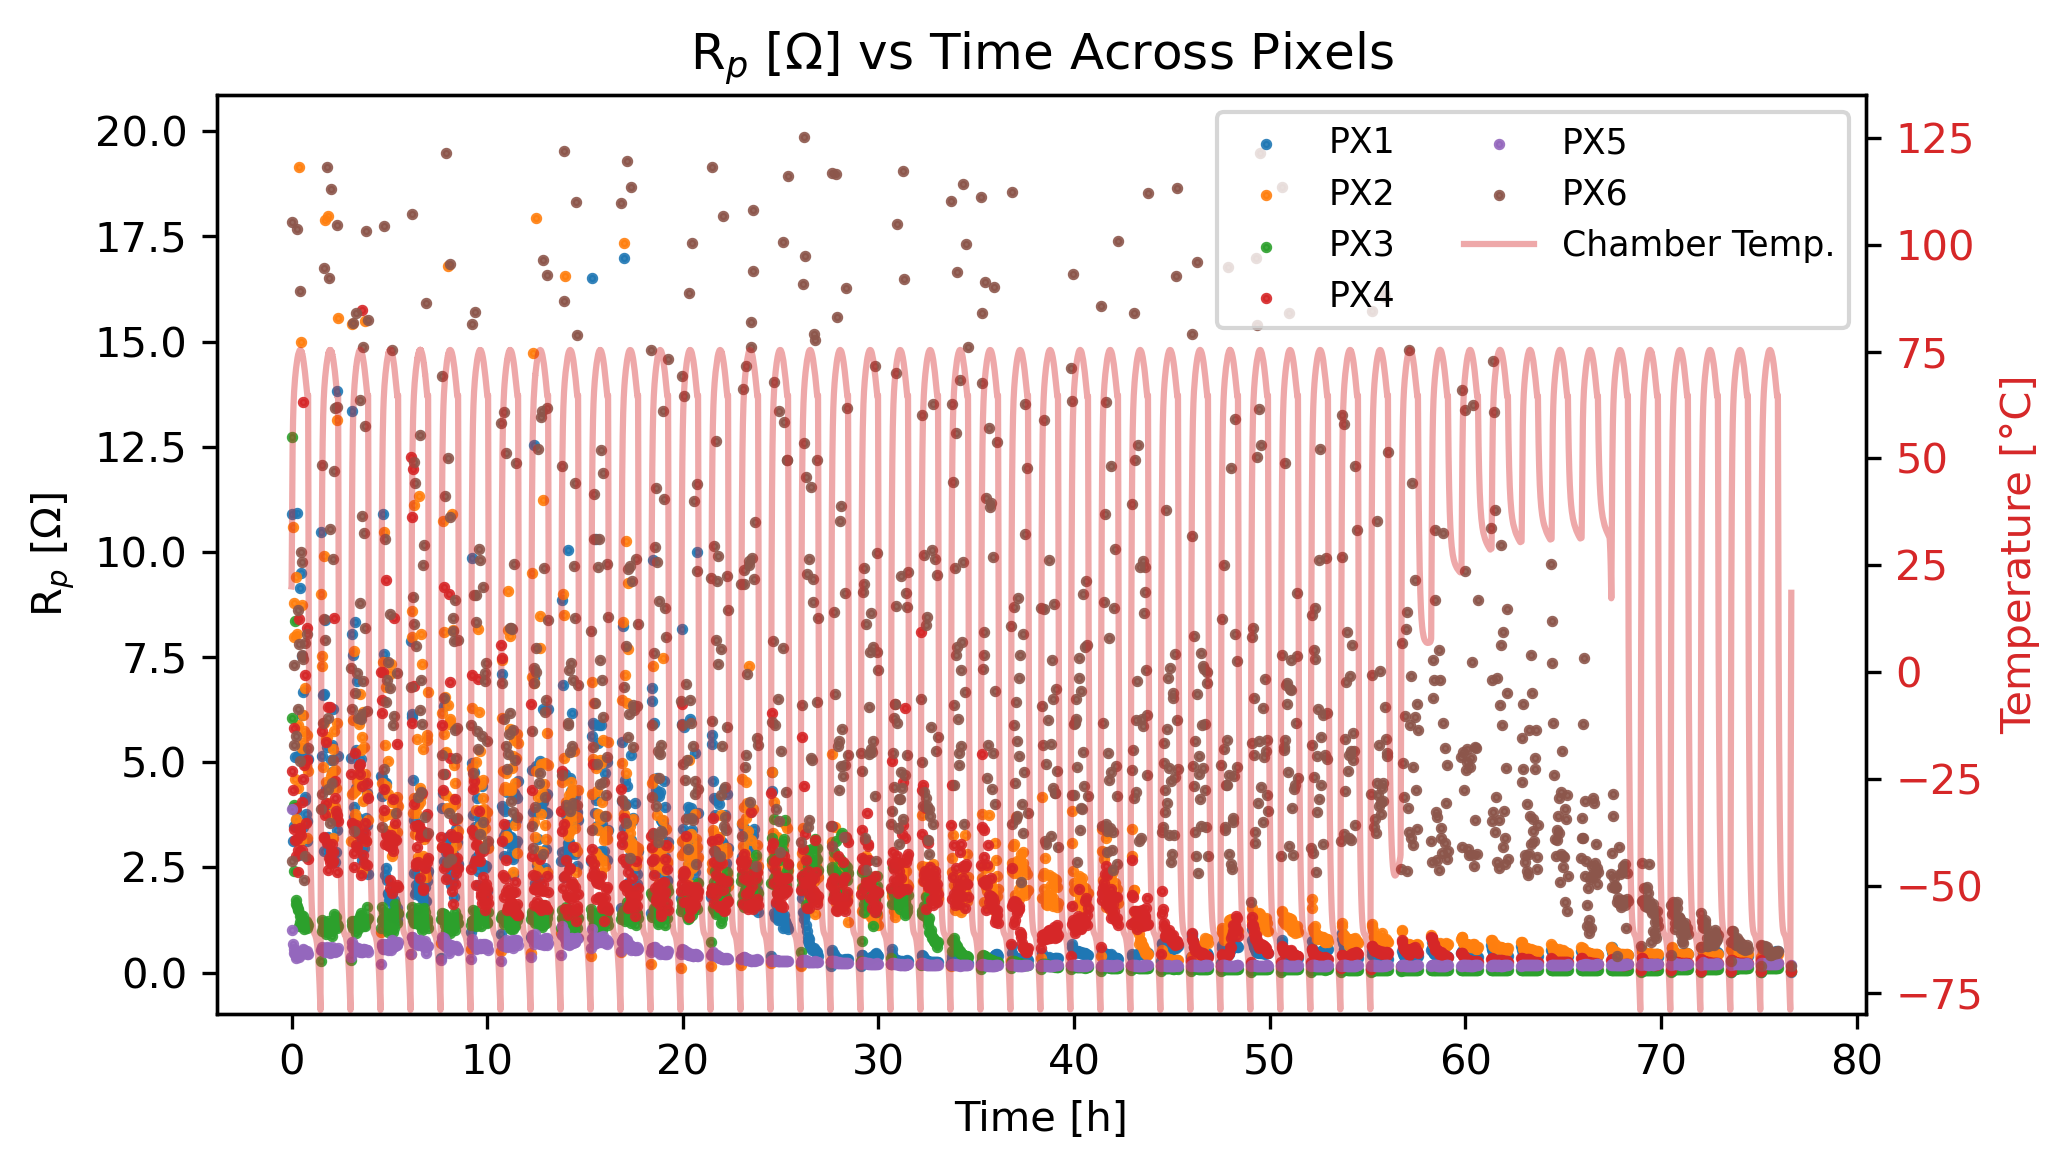

In [3]:

# Scatter plots for each photovoltaic parameter across pixels with chamber temperature overlay
PIXEL_COLOR_MAP = {
    'px1': '#1f77b4',
    'px2': '#ff7f0e',
    'px3': '#2ca02c',
    'px4': '#d62728',
    'px5': '#9467bd',
    'px6': '#8c564b',
}
PARAM_LABELS = {
    'Voc': 'Voc [V]',
    'Isc': r'I$_{sc}$ [mA/cm$^2$]',
    'FF': 'Fill Factor',
    'PCE': 'PCE [%]',
    'Rs': r'R$_s$ [Ω]',
    'Rp': r'R$_p$ [Ω]',
}
PARAM_YLIMS = {
    'PCE': (0, 20),
    'Voc': (0, 1.2),
    'Isc': (0, 8),
    'FF': (0, 1),
}
PIXEL_ORDER = sorted(per_pixel_arrays.keys())
PARAM_ORDER = ['Voc', 'Isc', 'FF', 'PCE', 'Rs', 'Rp']

if not len(temperature_timestamp_h) or not len(temperature_values_c):
    raise RuntimeError('Temperature arrays are empty; run the previous cell first.')

for param in PARAM_ORDER:
    fig, ax_left = plt.subplots(figsize=(7, 4), dpi=300)
    pixel_handles = []
    pixel_labels = []
    for pixel_key in PIXEL_ORDER:
        arrays = per_pixel_arrays[pixel_key]
        time_h = arrays['Timestamp_h']
        values = arrays[param]
        if time_h.size == 0 or values.size == 0:
            continue
        mask = np.isfinite(time_h) & np.isfinite(values)
        if not mask.any():
            continue
        scatter = ax_left.scatter(
            time_h[mask],
            values[mask],
            s=3,
            alpha=0.9,
            color=PIXEL_COLOR_MAP.get(pixel_key, '#333333'),
            label=pixel_key.upper()
        )
        pixel_handles.append(scatter)
        pixel_labels.append(pixel_key.upper())

    ax_left.set_xlabel('Time [h]')
    ax_left.set_ylabel(PARAM_LABELS.get(param, param))
    ax_left.set_title(f'{PARAM_LABELS.get(param, param)} vs Time Across Pixels')
    if param in PARAM_YLIMS:
        ax_left.set_ylim(*PARAM_YLIMS[param])

    ax_right = ax_left.twinx()
    temp_line, = ax_right.plot(
        temperature_timestamp_h,
        temperature_values_c,
        color='tab:red',
        alpha=0.4,
        linewidth=1.5,
        label='Chamber Temp.'
    )
    ax_right.set_ylabel('Temperature [°C]', color='tab:red')
    ax_right.tick_params(axis='y', labelcolor='tab:red')
    ax_right.set_ylim(-80, 135)

    handles = pixel_handles + [temp_line]
    labels = pixel_labels + ['Chamber Temp.']
    if handles:
        ax_left.legend(handles, labels, loc='upper right', fontsize='small', ncol=2)
    fig.tight_layout()
    plt.show()


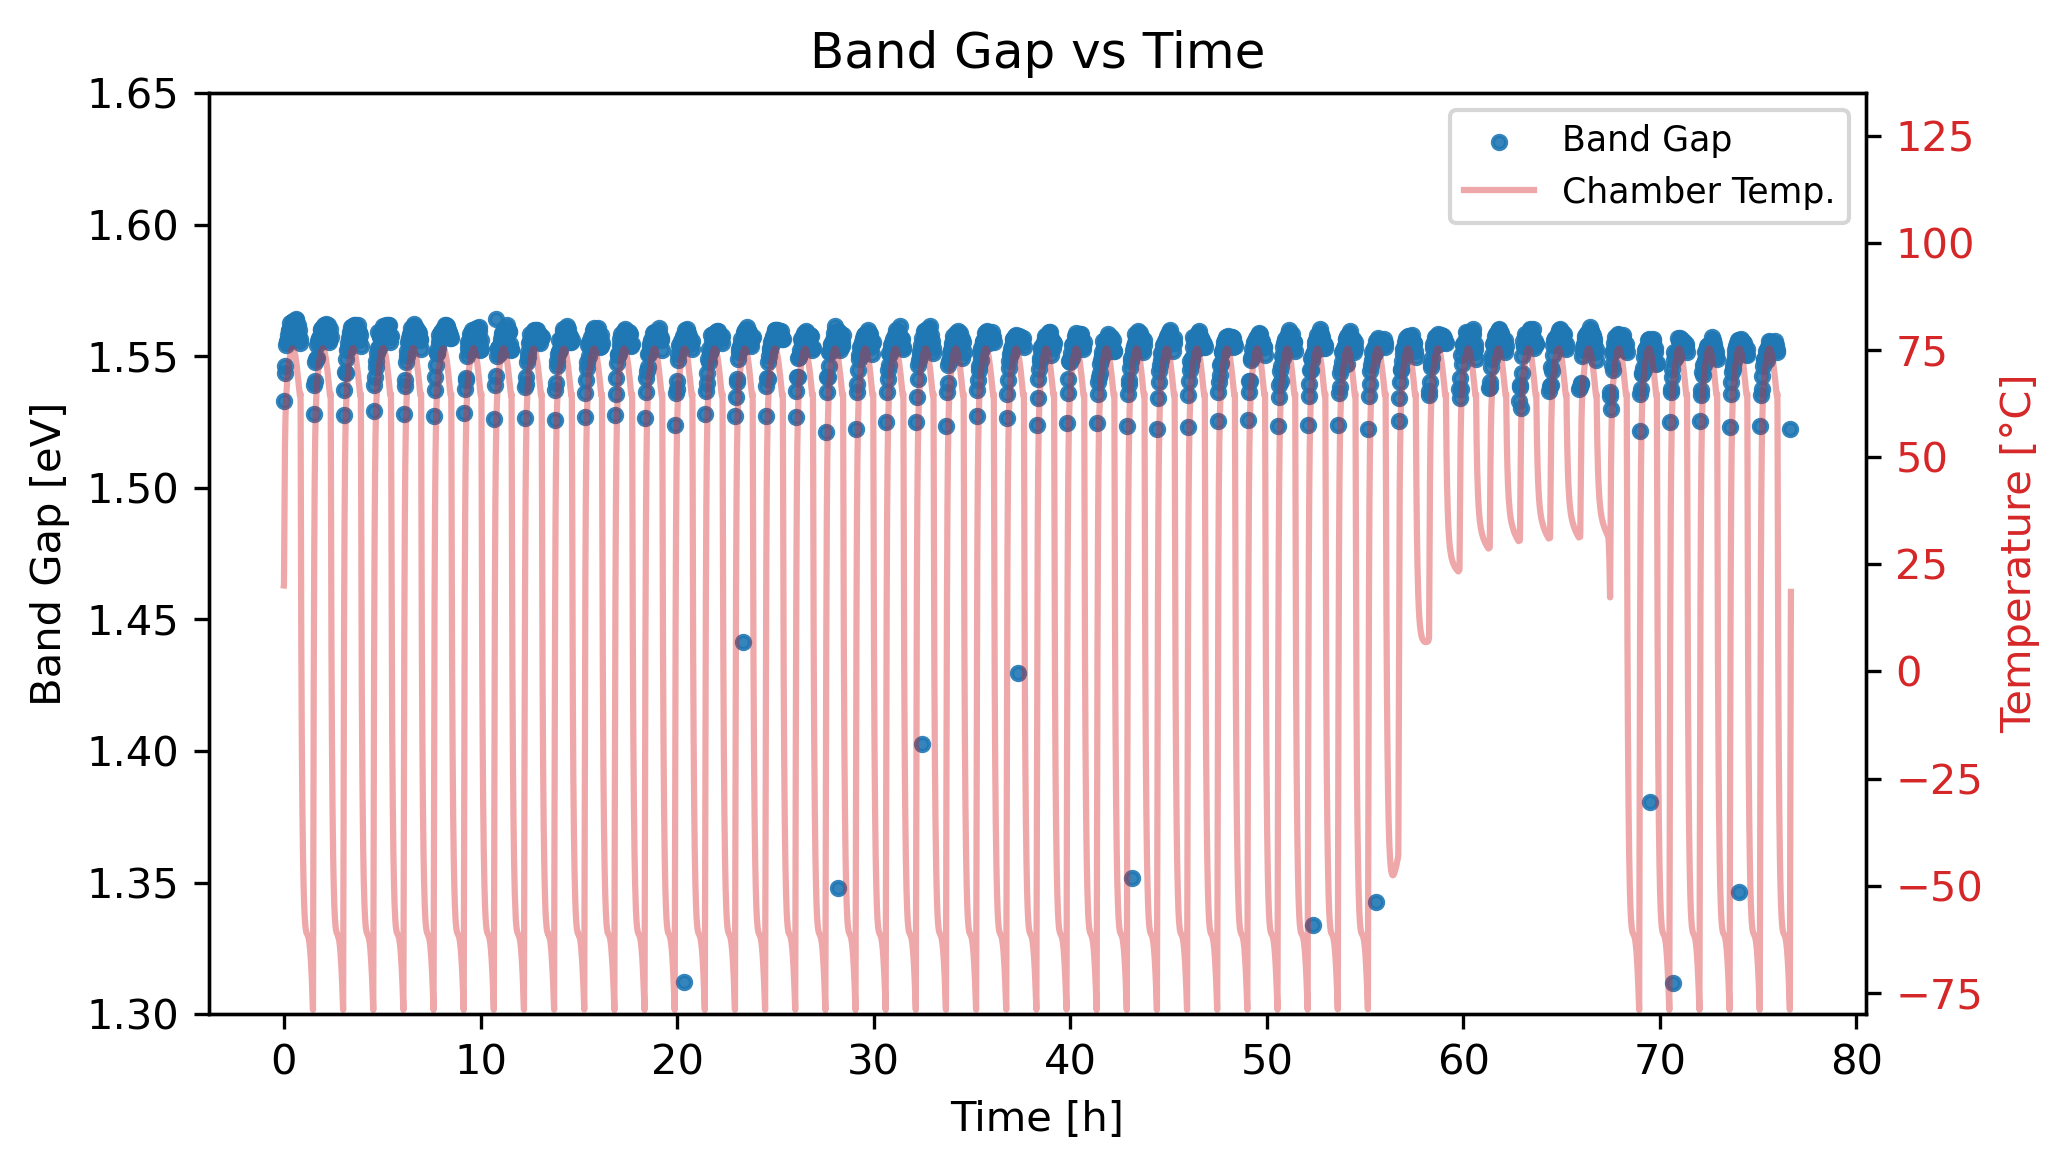

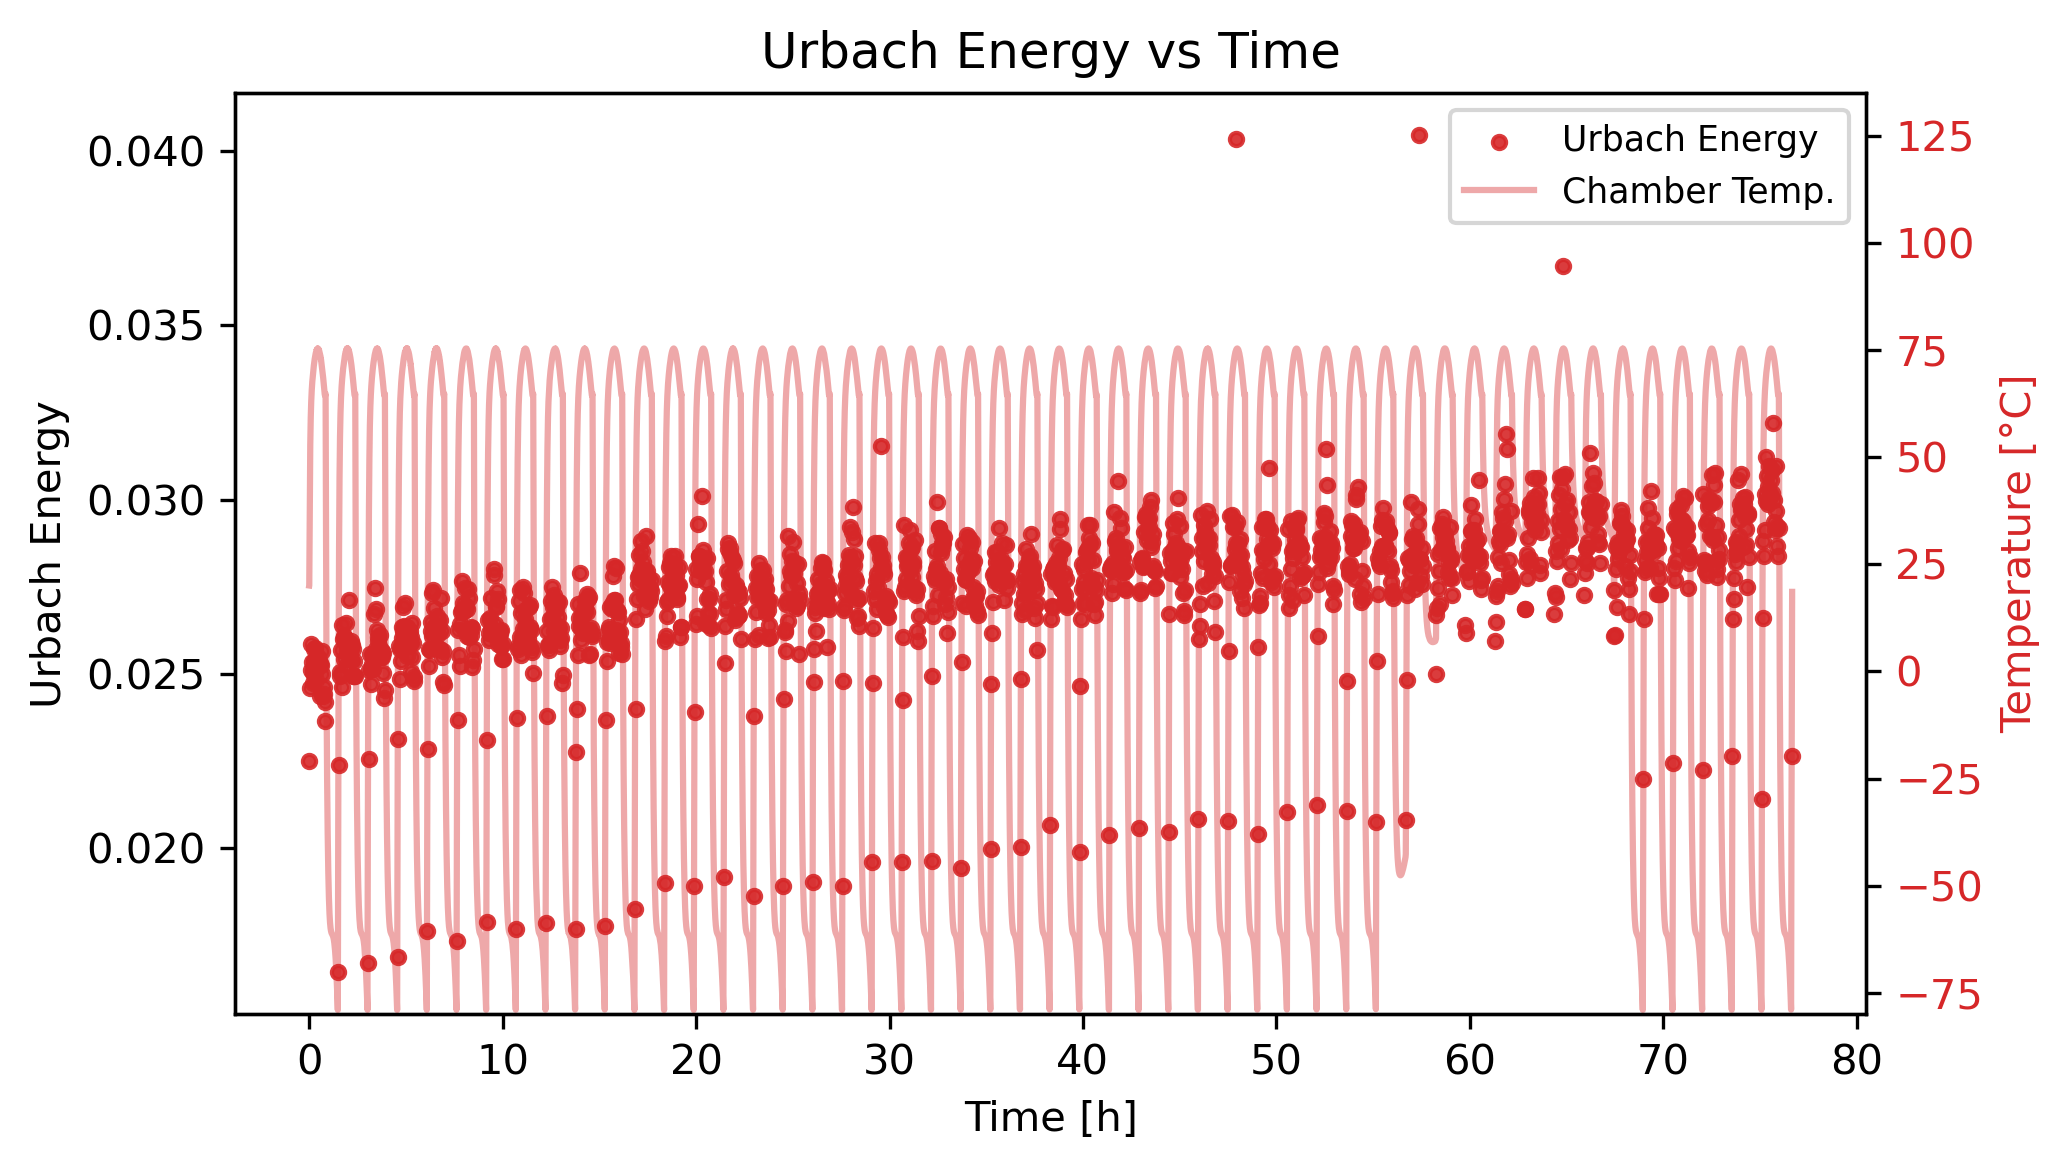

In [4]:

# Band gap and Urbach energy vs time with chamber temperature overlay
BAND_GAP_COLOR = '#1f77b4'
URBACH_COLOR = '#d62728'


def _series_to_numeric(series):
    return pd.to_numeric(series, errors='coerce')


def _resolve_time_series(df: pd.DataFrame, candidates):
    for entry in candidates:
        if isinstance(entry, tuple):
            column, scale = entry
        else:
            column, scale = entry, 1.0
        if column in df.columns:
            values = _series_to_numeric(df[column]) * scale
            if values.notna().any():
                return values
    raise KeyError(
        f"None of the time columns were found. Tried: {[c if isinstance(c, str) else c[0] for c in candidates]}"
    )


def _resolve_value_series(df: pd.DataFrame, columns):
    for column in columns:
        if column in df.columns:
            values = _series_to_numeric(df[column])
            if values.notna().any():
                return values
    raise KeyError(f"None of the candidate columns were found: {columns}")


SPECTRA_TIME_COLUMNS = (
    'time_hours',
    'measurement_time_h',
    ('measurement_time_s', 1 / 3600.0),
    ('Elapsed_s', 1 / 3600.0),
    'Elapsed_h',
    'timestamp(in Hour):',
)
URBACH_TIME_COLUMNS = (
    'timestamp(in Hour):',
    'time_hours',
    'measurement_time_h',
    ('measurement_time_s', 1 / 3600.0),
)

bandgap_time_h = _resolve_time_series(spectra_df, SPECTRA_TIME_COLUMNS)
bandgap_values = _resolve_value_series(spectra_df, ('band_gap',))
bandgap_mask = bandgap_time_h.notna() & bandgap_values.notna()

if bandgap_mask.any():
    fig, ax_left = plt.subplots(figsize=(7, 4), dpi=300)
    scatter_bg = ax_left.scatter(
        bandgap_time_h[bandgap_mask],
        bandgap_values[bandgap_mask],
        s=10,
        alpha=0.9,
        color=BAND_GAP_COLOR,
        label='Band Gap'
    )
    ax_left.set_xlabel('Time [h]')
    ax_left.set_ylabel('Band Gap [eV]')
    ax_left.set_ylim(1.3, 1.65)
    ax_left.set_title('Band Gap vs Time')

    ax_right = ax_left.twinx()
    temp_line_bg, = ax_right.plot(
        temperature_timestamp_h,
        temperature_values_c,
        color='tab:red',
        alpha=0.4,
        linewidth=1.5,
        label='Chamber Temp.'
    )
    ax_right.set_ylabel('Temperature [°C]', color='tab:red')
    ax_right.tick_params(axis='y', labelcolor='tab:red')
    ax_right.set_ylim(-80, 135)

    handles = [scatter_bg, temp_line_bg]
    labels = [h.get_label() for h in handles]
    ax_left.legend(handles, labels, loc='upper right', fontsize='small')
    fig.tight_layout()
    plt.show()
else:
    print('No valid band gap samples to plot.')

urbach_time_h = _resolve_time_series(urbach_df, URBACH_TIME_COLUMNS)
urbach_values = _resolve_value_series(urbach_df, ('urbach_energy',))
urbach_mask = urbach_time_h.notna() & urbach_values.notna()

if urbach_mask.any():
    fig, ax_left = plt.subplots(figsize=(7, 4), dpi=300)
    scatter_urb = ax_left.scatter(
        urbach_time_h[urbach_mask],
        urbach_values[urbach_mask],
        s=10,
        alpha=0.9,
        color=URBACH_COLOR,
        label='Urbach Energy'
    )
    ax_left.set_xlabel('Time [h]')
    ax_left.set_ylabel('Urbach Energy')
    ax_left.set_title('Urbach Energy vs Time')

    ax_right = ax_left.twinx()
    temp_line_urb, = ax_right.plot(
        temperature_timestamp_h,
        temperature_values_c,
        color='tab:red',
        alpha=0.4,
        linewidth=1.5,
        label='Chamber Temp.'
    )
    ax_right.set_ylabel('Temperature [°C]', color='tab:red')
    ax_right.tick_params(axis='y', labelcolor='tab:red')
    ax_right.set_ylim(-80, 135)

    handles = [scatter_urb, temp_line_urb]
    labels = [h.get_label() for h in handles]
    ax_left.legend(handles, labels, loc='upper right', fontsize='small')
    fig.tight_layout()
    plt.show()
else:
    print('No valid Urbach samples to plot.')
